In [ ]:
import torch
import numpy as np

import pulser
from pulser.register.special_layouts import SquareLatticeLayout, TriangularLatticeLayout

import dataclasses
from emu_mps.mps_backend_impl import create_impl
import emu_base
import emu_mps
from sympy.physics.quantum import represent
from sympy.physics.paulialgebra import Pauli
from sympy.physics.quantum import TensorProduct, Commutator
from sympy import I, simplify, symbols, diff, Function

from itertools import combinations, permutations

from counter_diabatic import (
    A_direct_mat,
    b_direct_vec,
    solve_cd_torch,
    solve_cd_tikhonov,
    pulse_to_Hamiltonian,
    compute_derivatives_analytical,
    Hamiltonian_to_pulse,
)
from counter_diabatic.utils_test import _extract_tp, _pauli_trace, tp_compose, tp_trace

In [2]:
n_qubits =2  # change to 3, 4, ...

# Pauli matrices
s1 = Pauli(1)  # σˣ
s2 = Pauli(2)  # σʸ
s3 = Pauli(3)  # σᶻ
I2 = Pauli(1) * Pauli(1)
nop = (I2 - s3) / 2  # projector onto |r⟩, we will this later
def single_body_op(pauli, site, n):
    factors = [I2] * n
    factors[site] = pauli
    return TensorProduct(*factors)

def two_body_op(pauli1, pauli2, site1, site2, n):
    factors = [I2] * n
    factors[site1] = pauli1
    factors[site2] = pauli2
    return TensorProduct(*factors)

# Single-site Pauli operators: X[i], Y[i], Z[i]  (0-indexed)
X = [single_body_op(s1, i, n_qubits) for i in range(n_qubits)]
Y = [single_body_op(s2, i, n_qubits) for i in range(n_qubits)]
Z = [single_body_op(s3, i, n_qubits) for i in range(n_qubits)]
N_op = [single_body_op(nop, i, n_qubits) for i in range(n_qubits)]

# Per-qubit drive amplitudes, phases, detunings
Omega = [symbols(f"Omega_{i+1}", real=True, positive=True) for i in range(n_qubits)]
Mu = [symbols(f"mu_{i+1}", real=True) for i in range(n_qubits)]
Nu = [symbols(f"nu_{i+1}", real=True) for i in range(n_qubits)]

# van der Waals couplings for each pair i < j
U = {
    (i, j): symbols(f"U{i+1}{j+1}", real=True, positive=True)
    for i, j in combinations(range(n_qubits), 2)
}

# Adiabatic scheduling parameter
lam = symbols("lambda", real=True)

# ── λ-dependent schedule functions ───────────────────────────────────────
Omega_l = [Function(f"Omega_{i+1}")(lam) for i in range(n_qubits)]
mu_l = [Function(f"mu_{i+1}")(lam) for i in range(n_qubits)]
nu_l = [Function(f"nu_{i+1}")(lam) for i in range(n_qubits)]


In [3]:
# do not delet this part
# ── Define the Hamiltonian ───────────────────────────────────────────────
# ── Static Hamiltonian ────────────────────────────────────────────────────
H = sum(
    Omega[i] * X[i] + Mu[i] * Y[i] + Nu[i] * Z[i]
    for i in range(n_qubits)
) + sum(
    U[(i,j)] * two_body_op(s3, s3, i, j, n_qubits)
    for i,j in combinations(range(n_qubits), 2)
)

# ── λ-dependent Hamiltonian (for dH/dλ) ──────────────────────────────────
H_lam = sum(
    Omega_l[i] * X[i] + mu_l[i] * Y[i] + nu_l[i] * Z[i]
    for i in range(n_qubits)
) + sum(
    U[(i,j)] * two_body_op(s3, s3, i, j, n_qubits)
    for i,j in combinations(range(n_qubits), 2)
)

dH_dlam = diff(H_lam, lam)


In [4]:
def make_cd_coeffs(n):
    """Generate all 2-body CD coefficients for n qubits."""
    a = {i: symbols(f'a_{i+1}', real=True) for i in range(n)}
    b = {i: symbols(f'b_{i+1}', real=True) for i in range(n)}
    c = {i: symbols(f'c_{i+1}', real=True) for i in range(n)}

    d_xx = {(i,j): symbols(f'delta_xx_{i+1}{j+1}', real=True) for i,j in combinations(range(n), 2)}
    d_yy = {(i,j): symbols(f'delta_yy_{i+1}{j+1}', real=True) for i,j in combinations(range(n), 2)}
    d_zz = {(i,j): symbols(f'delta_zz_{i+1}{j+1}', real=True) for i,j in combinations(range(n), 2)}

    d_xy = {(i,j): symbols(f'delta_xy_{i+1}{j+1}', real=True) for i,j in permutations(range(n), 2)}
    d_xz = {(i,j): symbols(f'delta_xz_{i+1}{j+1}', real=True) for i,j in permutations(range(n), 2)}
    d_yz = {(i,j): symbols(f'delta_yz_{i+1}{j+1}', real=True) for i,j in permutations(range(n), 2)}

    return a, b, c, d_xx, d_yy, d_zz, d_xy, d_xz, d_yz

def make_ansatz(n):
    """Build ansatz A as a sum of scalar * TensorProduct terms."""
    a, b, c, d_xx, d_yy, d_zz, d_xy, d_xz, d_yz = make_cd_coeffs(n)

    A = sum(
          a[i] * single_body_op(s1, i, n) # for the moment, ignore single-body X terms
        + b[i] * single_body_op(s2, i, n)
        + c[i] * single_body_op(s3, i, n) # for the moment, ignore single-body Z terms
        for i in range(n)
    )
    for i,j in combinations(range(n), 2):
        A += d_xx[(i,j)] * two_body_op(s1, s1, i, j, n)
        A += d_yy[(i,j)] * two_body_op(s2, s2, i, j, n)
        A += d_zz[(i,j)] * two_body_op(s3, s3, i, j, n)
    for i,j in permutations(range(n), 2):
        A += d_xy[(i,j)] * two_body_op(s1, s2, i, j, n)
        A += d_xz[(i,j)] * two_body_op(s1, s3, i, j, n)
        A += d_yz[(i,j)] * two_body_op(s2, s3, i, j, n)

    return A, a, b, c, d_xx, d_yy, d_zz, d_xy, d_xz, d_yz

# ── Tests ─────────────────────────────────────────────────────────────────

for n in [2, 3, 4]:
    a, b, c, d_xx, d_yy, d_zz, d_xy, d_xz, d_yz = make_cd_coeffs(n)

    n_single = 3 * n
    n_sym    = 3 * len(list(combinations(range(n), 2)))   # 3 * C(n,2)
    n_asym   = 3 * len(list(permutations(range(n), 2)))   # 3 * n*(n-1)
    n_total  = n_single + n_sym + n_asym

    print(f"n={n}: single={n_single}, sym={n_sym}, asym={n_asym}, total={n_total}  (4^n-1={4**n-1}) with 3 body terms")

    # spot-check: correct symbol names
    assert a[0].name == 'a_1'
    assert d_xx[(0,1)].name == 'delta_xx_12'
    assert d_xy[(1,0)].name == 'delta_xy_21'
    if n >= 3:
        assert d_yz[(2,0)].name == 'delta_yz_31'

    # no duplicate symbols
    all_syms = (list(a.values()) + list(b.values()) + list(c.values()) +
                list(d_xx.values()) + list(d_yy.values()) + list(d_zz.values()) +
                list(d_xy.values()) + list(d_xz.values()) + list(d_yz.values()))
    assert len(all_syms) == len(set(s.name for s in all_syms)), "duplicate symbols!"

    print(f"     all assertions passed")
    print(f"     sample symbols: {a[0]}, {d_xx[(0,1)]}, {d_xy[(1,0)]}")


n=2: single=6, sym=3, asym=6, total=15  (4^n-1=15) with 3 body terms
     all assertions passed
     sample symbols: a_1, delta_xx_12, delta_xy_21
n=3: single=9, sym=9, asym=18, total=36  (4^n-1=63) with 3 body terms
     all assertions passed
     sample symbols: a_1, delta_xx_12, delta_xy_21
n=4: single=12, sym=18, asym=36, total=66  (4^n-1=255) with 3 body terms
     all assertions passed
     sample symbols: a_1, delta_xx_12, delta_xy_21


In [5]:
a, b, c, d_xx, d_yy, d_zz, d_xy, d_xz, d_yz = make_cd_coeffs(n_qubits)
A, a, b, c, d_xx, d_yy, d_zz, d_xy, d_xz, d_yz = make_ansatz(n_qubits)
A

a_1*sigma1x1 + a_2*1xsigma1 + b_1*sigma2x1 + b_2*1xsigma2 + c_1*sigma3x1 + c_2*1xsigma3 + delta_xx_12*sigma1xsigma1 + delta_xy_12*sigma1xsigma2 + delta_xy_21*sigma2xsigma1 + delta_xz_12*sigma1xsigma3 + delta_xz_21*sigma3xsigma1 + delta_yy_12*sigma2xsigma2 + delta_yz_12*sigma2xsigma3 + delta_yz_21*sigma3xsigma2 + delta_zz_12*sigma3xsigma3

In [6]:
icommutator = ((I*Commutator(A,H).expand(commutator=True)).expand(commutator=True).doit())

In [7]:
CD = dH_dlam + icommutator #G
CD

2*Omega_1*b_1*sigma3x1 - 2*Omega_1*c_1*sigma2x1 + 2*Omega_1*delta_xy_21*sigma3xsigma1 - 2*Omega_1*delta_xz_21*sigma2xsigma1 + 2*Omega_1*delta_yy_12*sigma3xsigma2 + 2*Omega_1*delta_yz_12*sigma3xsigma3 - 2*Omega_1*delta_yz_21*sigma2xsigma2 - 2*Omega_1*delta_zz_12*sigma2xsigma3 + 2*Omega_2*b_2*1xsigma3 - 2*Omega_2*c_2*1xsigma2 + 2*Omega_2*delta_xy_12*sigma1xsigma3 - 2*Omega_2*delta_xz_12*sigma1xsigma2 + 2*Omega_2*delta_yy_12*sigma2xsigma3 - 2*Omega_2*delta_yz_12*sigma2xsigma2 + 2*Omega_2*delta_yz_21*sigma3xsigma3 - 2*Omega_2*delta_zz_12*sigma3xsigma2 + 2*U12*a_1*sigma2xsigma3 + 2*U12*a_2*sigma3xsigma2 - 2*U12*b_1*sigma1xsigma3 - 2*U12*b_2*sigma3xsigma1 + 2*U12*delta_xz_12*sigma2x1 + 2*U12*delta_xz_21*1xsigma2 - 2*U12*delta_yz_12*sigma1x1 - 2*U12*delta_yz_21*1xsigma1 - 2*a_1*mu_1*sigma3x1 + 2*a_1*nu_1*sigma2x1 - 2*a_2*mu_2*1xsigma3 + 2*a_2*nu_2*1xsigma2 - 2*b_1*nu_1*sigma1x1 - 2*b_2*nu_2*1xsigma1 + 2*c_1*mu_1*sigma1x1 + 2*c_2*mu_2*1xsigma1 - 2*delta_xx_12*mu_1*sigma3xsigma1 - 2*delta_xx_12

In [8]:
tp_trace(tp_compose(X[0], CD),n_qubits)/2**(n_qubits+1)

-U12*delta_yz_12 - b_1*nu_1 + c_1*mu_1 + Derivative(Omega_1(lambda), lambda)/2

In [9]:
if n_qubits == 2:
    expected = -Omega[0]*d_yz[(1,0)]-Omega[1]*d_yz[(0,1)]+d_xy[(0,1)]*Nu[0]+d_xy[(1,0)]*Nu[1]
    assert simplify(tp_trace(tp_compose(Y[0]*Y[1], CD),n_qubits)/2**(n_qubits+1) - expected) == 0
    
    expected = -b[0]*Nu[0]+c[0]*Mu[0]-d_yz[(0,1)]*U[(0,1)]+diff(Omega_l[0],lam)/2
    assert (tp_trace(tp_compose(X[0], CD),n_qubits)/2**(n_qubits+1)).equals(expected)
    
    expected = a[1]*Nu[1]-c[1]*Omega[1]+d_xz[(1,0)]*U[(0,1)]+diff(mu_l[1],lam)/2
    assert (tp_trace(tp_compose(Y[1], CD),n_qubits)/2**(n_qubits+1)).equals(expected)


In [10]:
if n_qubits == 3:
    expected = -Omega[0]*d_yz[(1,0)]-Omega[1]*d_yz[(0,1)]+d_xy[(0,1)]*Nu[0]+d_xy[(1,0)]*Nu[1]
    assert simplify(tp_trace(tp_compose(Y[0]*Y[1], CD),n_qubits)/2**(n_qubits+1) - expected) == 0

    expected = -Omega[1]*d_yz[(2,1)]-Omega[2]*d_yz[(1,2)]+d_xy[(1,2)]*Nu[1]+d_xy[(2,1)]*Nu[2]
    assert simplify(tp_trace(tp_compose(Y[1]*Y[2], CD),n_qubits)/2**(n_qubits+1)- expected) == 0

    # 3 qubit terms
    expected = -U[(0,2)]*d_yy[(0,1)]+U[(1,2)]*d_xx[(0,1)]
    assert simplify(tp_trace(tp_compose(X[0]*Y[1]*Z[2], CD),n_qubits)/2**(n_qubits+1) - expected) == 0
    #3 qubit terms
    expected = -U[(0,1)]*d_yz[(0,2)]-U[(0,2)]*d_yz[(0,1)]
    assert simplify(tp_trace(tp_compose(X[0]*Z[1]*Z[2], CD),n_qubits)/2**(n_qubits+1) - expected) == 0

In [11]:
tp_trace(tp_compose(Z[0], CD),n_qubits)/2**(n_qubits+1) 

Omega_1*b_1 - a_1*mu_1 + Derivative(nu_1(lambda), lambda)/2

In [12]:
# ── Pauli basis (same ordering as ansatz A) ──────────────────────────────
def make_basis_ops(n):
    """Return (ops, eq_labels, x_labels): rows=equations, cols=unknowns."""
    ops, eq_labels, x_labels = [], [], []

    def paired_permutations(n):
        return [
            (i, j) for i, j in combinations(range(n), 2) for i, j in [(i, j), (j, i)]
        ]

    for i in range(n):
        ops.append(single_body_op(s1, i, n))
        eq_labels.append(f"X{i+1}")
        x_labels.append(f"a_{i+1}")
        ops.append(single_body_op(s2, i, n))
        eq_labels.append(f"Y{i+1}")
        x_labels.append(f"b_{i+1}")
        ops.append(single_body_op(s3, i, n))
        eq_labels.append(f"Z{i+1}")
        x_labels.append(f"c_{i+1}")
    for i, j in combinations(range(n), 2):
        ops.append(two_body_op(s1, s1, i, j, n)); eq_labels.append(f'X{i+1}X{j+1}'); x_labels.append(f'dxx_{i+1}{j+1}')
        ops.append(two_body_op(s2, s2, i, j, n)); eq_labels.append(f'Y{i+1}Y{j+1}'); x_labels.append(f'dyy_{i+1}{j+1}')
        ops.append(two_body_op(s3, s3, i, j, n)); eq_labels.append(f'Z{i+1}Z{j+1}'); x_labels.append(f'dzz_{i+1}{j+1}')
    for i, j in paired_permutations(n):
        ops.append(two_body_op(s1, s2, i, j, n)); eq_labels.append(f'X{i+1}Y{j+1}'); x_labels.append(f'dxy_{i+1}{j+1}')
        ops.append(two_body_op(s1, s3, i, j, n)); eq_labels.append(f'X{i+1}Z{j+1}'); x_labels.append(f'dxz_{i+1}{j+1}')
        ops.append(two_body_op(s2, s3, i, j, n)); eq_labels.append(f'Y{i+1}Z{j+1}'); x_labels.append(f'dyz_{i+1}{j+1}')
    return ops, eq_labels, x_labels


# ── Build constant coefficient tensors (symbolic, done once) ─────────────


def build_coefficient_tensors(n):
    """
    Exploits linearity of H to decompose M and b into parameter-free matrices:

        M(Ω,μ,ν,U) = Σ_k [ Ω_k·M_Om[k] + μ_k·M_Mu[k] + ν_k·M_Nu[k] ]
                     + Σ_{k<l} U_kl · M_U[(k,l)]

        b(Ω̇,μ̇,ν̇)  = Σ_k [ Ω̇_k·b_Om[k] + μ̇_k·b_Mu[k] + ν̇_k·b_Nu[k] ]

    where M[i,j] = Tr(P_i · i[P_j, H_unit]) / 2^(n+1)  (one H term at a time)
          b[i]   = -Tr(P_i · dH_unit)       / 2^(n+1)

    Each returned object is a constant float64 torch tensor (no grad).
    """
    basis_ops, _, _ = make_basis_ops(n)
    norm = 2 ** (n +1)
    N = len(basis_ops)

    def _M_for(H_unit):
        mat = np.zeros((N, N))
        for i, P_i in enumerate(basis_ops):
            for j, P_j in enumerate(basis_ops):
                comm = (
                    (I * Commutator(P_j, H_unit).expand(commutator=True))
                    .expand(commutator=True)
                    .doit()
                )
                if comm == 0:
                    continue
                mat[i, j] = float(tp_trace(tp_compose(P_i, comm), n) / norm)
        return torch.tensor(mat, dtype=torch.float64)

    def _b_for(dH_unit):
        vec = np.zeros(N)
        for i, P_i in enumerate(basis_ops):
            entry = -tp_trace(tp_compose(P_i, dH_unit), n) / norm
            if entry == 0:
                continue
            vec[i] = float(entry)
        return torch.tensor(vec, dtype=torch.float64)

    print(f"Building coefficient tensors  n={n}  N={N} ...")
    M_Om = [_M_for(single_body_op(s1, k, n)) for k in range(n)]
    M_Mu = [_M_for(single_body_op(s2, k, n)) for k in range(n)]
    M_Nu = [_M_for(single_body_op(s3, k, n)) for k in range(n)]
    M_U = {
        (i, j): _M_for(two_body_op(s3, s3, i, j, n))
        for i, j in combinations(range(n), 2)
    }
    b_Om = [_b_for(single_body_op(s1, k, n)) for k in range(n)]
    b_Mu = [_b_for(single_body_op(s2, k, n)) for k in range(n)]
    b_Nu = [_b_for(single_body_op(s3, k, n)) for k in range(n)]
    return M_Om, M_Mu, M_Nu, M_U, b_Om, b_Mu, b_Nu


def make_M_torch(M_Om, M_Mu, M_Nu, M_U, Omega, Mu, Nu, U) -> torch.Tensor:
    """Assemble M — gradients flow through Omega/Mu/Nu/U."""
    # change this sum to stack().sum(dim=0)
    M = sum(
        Omega[k] * M_Om[k] + Mu[k] * M_Mu[k] + Nu[k] * M_Nu[k]
        for k in range(len(Omega))
    )
    for (i, j), M_ij in M_U.items():
        M = M + U[(i, j)] * M_ij
    #  = torch.stack(
    # [
    # Omega[k] * M_Om[k]
    # + Mu[k] * M_Mu[k]
    # + Nu[k] * M_Nu[k]
    # for k in range(len(Omega))
    # ]
    # ).sum(dim=0) , then add the interaction terms
    return M


def make_b_torch(b_Om, b_Mu, b_Nu, dOmega, dMu, dNu) -> torch.Tensor:
    """Assemble b — gradients flow through dOmega/dMu/dNu."""
    return sum(
        dOmega[k] * b_Om[k] + dMu[k] * b_Mu[k] + dNu[k] * b_Nu[k]
        for k in range(len(dOmega))
    )

In [13]:
# step 1: build constant tensors

n_cd = 2  # change to 3 for full system

M_Om, M_Mu, M_Nu, M_U, b_Om, b_Mu, b_Nu = build_coefficient_tensors(n_cd)
_, _, x_labels_cd = make_basis_ops(n_cd)

# torch tensors with requires_grad=True
# Hamiltonian parameters
Omega_t = [
    torch.tensor(11.0 + 0.1 * k, dtype=torch.float64, requires_grad=True)
    for k in range(n_cd)
]
Mu_t = [
    torch.tensor(3.0 + 0.0 * k, dtype=torch.float64, requires_grad=True)
    for k in range(n_cd)
]
Nu_t = [
    torch.tensor(5.0 + 0.1 * k, dtype=torch.float64, requires_grad=True)
    for k in range(n_cd)
]
U_t = {
    (i, j): torch.tensor(
        13.0 + 0.1 * i + 0.01 * j, dtype=torch.float64, requires_grad=True
    )
    for i, j in combinations(range(n_cd), 2)
}
# Schedule derivatives at current lambda (change per lambda step)
dOmega_t = [
    torch.tensor(11.3 * (-1) ** k, dtype=torch.float64, requires_grad=True)
    for k in range(n_cd)
]
dMu_t = [
    torch.tensor(1.0, dtype=torch.float64, requires_grad=True) for _ in range(n_cd)
]
dNu_t = [
    torch.tensor(5.1 * (-1) ** k, dtype=torch.float64, requires_grad=True)
    for k in range(n_cd)
]

# Step 3: assemble and solve — autograd graph
M_t = make_M_torch(M_Om, M_Mu, M_Nu, M_U, Omega_t, Mu_t, Nu_t, U_t)
b_t = make_b_torch(b_Om, b_Mu, b_Nu, dOmega_t, dMu_t, dNu_t)
M_t, b_t

Building coefficient tensors  n=2  N=15 ...


(tensor([[  0.0000,  -5.0000,   3.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000, -13.0100,   0.0000,   0.0000,
            0.0000],
         [  5.0000,   0.0000, -11.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,  13.0100,   0.0000,   0.0000,   0.0000,
            0.0000],
         [ -3.0000,  11.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
            0.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,  -5.1000,   3.0000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          -13.0100],
         [  0.0000,   0.0000,   0.0000,   5.1000,   0.0000, -11.1000,   0.0000,
            0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,  13.0100,
            0.0000],
         [  0.0000,   0.0000,   0.0000,  -3.0000,  11.1000,   0.0000,   0.0000,
            0.0

In [14]:
## M_t is correct and create A_matrix from the sequece
n_atoms = 2
n_single = 3 * n_atoms 
n_sym    = 3 * len(list(combinations(range(n_atoms), 2)))   # 3 * C(n,2)
n_asym   = 3 * len(list(permutations(range(n_atoms), 2)))   # 3 * n*(n-1)
n_total  = n_single + n_sym + n_asym

A_matrix = A_direct_mat(n_atoms, Omega_t, Mu_t, Nu_t, U_t)
assert torch.allclose(A_matrix,M_t)

b_vector = b_direct_vec(n_atoms, dOmega_t, dMu_t, dNu_t)
    
assert torch.allclose(b_vector,b_t)

In [15]:
# soves the system A_matrix x = b_vector, using paulis
#x_t = solve_cd_torch(M_t, b_t)
#x_t = solve_cd_tikhonov(M_t, b_t)

In [16]:
# using direct A and b formation

# x_t_Amat = solve_cd_tikhonov(A_matrix, b_vector)
# print("CD coefficients x:")
# for lbl, val in zip(x_labels_cd, x_t_Amat.tolist()):
#     print(f"  {lbl:20s} = {val:+.6f}")

#assert torch.allclose(x_t, x_t_Amat)

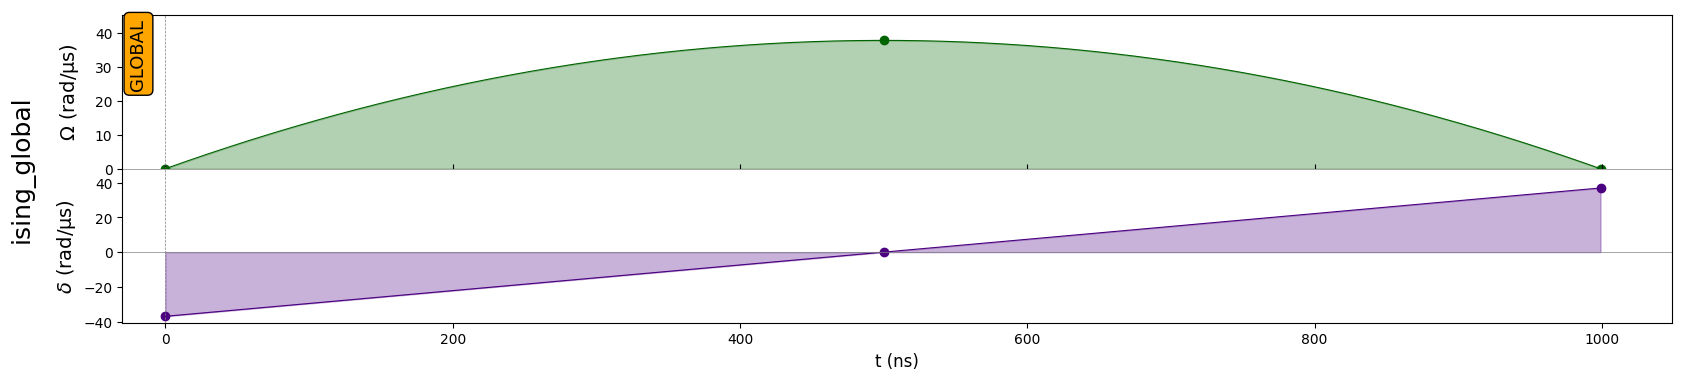

In [17]:
## pulser sequence

om_max_rabi = 1 * np.pi * 4.0
num_atoms = 2
square_layout = TriangularLatticeLayout(7, spacing=8)
square_register = square_layout.define_register(0,1)
positions = square_register.sorted_coords
#num_atoms = len(positions)

positions = square_register.sorted_coords
#positions = {"q"+str(i): pos for i, pos in enumerate(positions)}
#reg = pulser.Register(positions)
reg = pulser.Register.rectangle(1, num_atoms, prefix="q",spacing=torch.tensor(7.0))

T = 1000
delta_0 = -37
delta_f = 37
adiabatic_pulse = pulser.Pulse(
    pulser.InterpolatedWaveform(T, [1e-9, 3*om_max_rabi, 1e-9]),
    pulser.InterpolatedWaveform(T, [delta_0, 0, delta_f]),
    0,
)
seq = pulser.Sequence(reg, pulser.MockDevice)
seq.declare_channel("ising_global", "rydberg_global")
seq.add(adiabatic_pulse, "ising_global")
seq.draw()



In [18]:
dt = 10
emu_mps_config = emu_mps.MPSConfig()
pulser_data = emu_base.pulser_adapter.PulserData(sequence=seq,config=emu_mps_config,dt=dt)

/home/mauro/Documents/pasqal/code/.venv/lib/python3.10/site-packages/emu_mps/mps_config.py:111: UserWarning: 'MPSConfig' was initialized without any observables. The corresponding emulation results will be empty.
  super().__init__(


In [19]:
eval_times = [1.0]
mps_config = emu_mps.MPSConfig(
        dt=dt,
        precision=1e-5,
        observables=[
            emu_mps.Occupation(evaluation_times=eval_times),
            emu_mps.BitStrings(evaluation_times=eval_times, num_shots=1000),
            #emu_mps.Energy(evaluation_times=eval_times),
            #emu_mps.EnergyVariance(evaluation_times=eval_times),
            #emu_mps.EnergySecondMoment(evaluation_times=eval_times),
            #emu_mps.CorrelationMatrix(evaluation_times=eval_times),
            emu_mps.StateResult(evaluation_times=eval_times),
            #emu_mps.Fidelity(evaluation_times=eval_times, state=fidelity_state, tag_suffix="1"),
        ],
        #noise_model=noise_model,
        #interaction_cutoff=interaction_cutoff,
        #optimize_qubit_ordering=optimize_qubit_ordering,
        #solver=solver,
    log_level=100)

backend = emu_mps.MPSBackend(seq, config=mps_config)

result = backend.run()

In [20]:
ocupation = result.occupation[-1]
print(ocupation)
bitstrings = result.bitstrings[-1]
print(bitstrings)

tensor([0.5419, 0.5419], dtype=torch.float64)
Counter({'10': 453, '01': 433, '11': 94, '00': 20})


In [21]:
# changing data directly from pulser_data
sequence_data = pulser_data.get_sequences()
omegas = [i.omega.to(dtype=torch.float64).requires_grad_(True) for i in sequence_data]
sequence_data = pulser_data.get_sequences()
deltas = [i.delta.to(dtype=torch.float64).requires_grad_(True) for i in sequence_data]
sequence_data = pulser_data.get_sequences()
sequence_data = pulser_data.get_sequences()
phis = [i.phi.to(dtype=torch.float64).requires_grad_(True) for i in sequence_data]
#sequence_data = pulser_data.get_sequences()
#times = [i.target_times for i in sequence_data]
# sequence_data = pulser_data.get_sequences()
# # Get matrix at a specific time t (float, in ns)
# interact = [i.interaction_matrix(0.0) for i in sequence_data]
# sequence_data = pulser_data.get_sequences()
# # Or get both explicitly
# interact_masked = [i.interaction_matrix.masked_matrix for i in sequence_data]
sequence_data = pulser_data.get_sequences()
interact_full   = [i.interaction_matrix.full_matrix   for i in sequence_data]

/tmp/ipykernel_264666/1516372447.py:3: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /pytorch/aten/src/ATen/native/Copy.cpp:309.)
  omegas = [i.omega.to(dtype=torch.float64).requires_grad_(True) for i in sequence_data]


In [22]:
omegas= omegas[0] # only torch tensors, not lists
deltas= deltas[0]
phis= phis[0]
interact_mat = interact_full[0]  # (n_atoms, n_atoms), time-independent 

In [23]:
Omega_H, Mu_H, Nu_H = pulse_to_Hamiltonian(omegas, deltas, phis)
dOmega_H, dMu_H, dNu_H = compute_derivatives_analytical(omegas, deltas, phis, dt)

In [24]:
def compute_cd_correction_diff_adapted(
    omegas_base, deltas_base, phis_base, interact_mat, num_atoms, dt
):
    """
    Single-body CD gauge potential correction.
    The CD gauge potential in our ansatz is:
        A_CD = sum_i  a_i*X_i + b_i*Y_i + c_i*Z_i  +  (2-body, dropped)
    Coefficients come from solving A·x = b at each time step.
    The single-body block has order (a_0, b_0, c_0, a_1, b_1, c_1, ...).
    Adding A_CD to H changes the Hamiltonian coefficients:
        X_i:  Omega_H + a_i
        Y_i:  Mu_H   + b_i
        Z_i:  Nu_H   + c_i   (Nu_H = -delta,  so delta_new = delta - c_i)
    Then we convert back to pulse parametrisation:
        omega_cd = 2 * sqrt( (Omega_H + a)^2 + (Mu_H + b)^2 )
        phi_cd   = atan2( Mu_H + b,  Omega_H + a )
        delta_cd = delta_orig - c
    """
    M_Om, M_Mu, M_Nu, M_U, b_Om, b_Mu, b_Nu = build_coefficient_tensors(num_atoms)
    #_, _, x_labels_cd = make_basis_ops(n_atoms)

    Omega_H, Mu_H, Nu_H = pulse_to_Hamiltonian(omegas_base, deltas_base, phis_base)
    dOmega_H, dMu_H, dNu_H = compute_derivatives_analytical(
        omegas_base, deltas_base, phis_base, dt
    )

    a_list, b_list, c_list = [], [], []
    for k in range(len(omegas_base)):
        M_t = make_M_torch(
            M_Om, M_Mu, M_Nu, M_U, Omega_H[k], Mu_H[k], Nu_H[k], interact_mat
        )
        b_t = 100*make_b_torch(b_Om, b_Mu, b_Nu, dOmega_H[k], dMu_H[k], dNu_H[k])
        coeffs = solve_cd_tikhonov(M_t, b_t, lam=1e-4)

        print(M_t)
        print(b_t)
        print(coeffs)

        a_list.append(coeffs[0 : 3 * num_atoms : 3])  # X for each qubit
        b_list.append(coeffs[1 : 3 * num_atoms : 3])  # Y
        c_list.append(coeffs[2 : 3 * num_atoms : 3])  # Z

    # print(coeffs)
    a_corr = torch.stack(a_list)  # (T, n_atoms) — has grad_fn
    b_corr = torch.stack(b_list)
    c_corr = torch.stack(c_list)

    omega_cd, delta_cd, phi_cd = Hamiltonian_to_pulse(
        Omega_H, Mu_H, Nu_H, a_corr, b_corr, c_corr
    )

    return omega_cd, delta_cd, phi_cd

In [25]:
omega_sol, delta_sol, phi_sol = compute_cd_correction_diff_adapted(
    omegas, deltas, phis, interact_mat, num_atoms, dt)

Building coefficient tensors  n=2  N=15 ...
tensor([[  0.0000, -36.6304,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
           0.0000,   0.0000,   0.0000,   0.0000, -46.0706,   0.0000,   0.0000,
           0.0000],
        [ 36.6304,   0.0000,  -0.7510,   0.0000,   0.0000,   0.0000,   0.0000,
           0.0000,   0.0000,   0.0000,  46.0706,   0.0000,   0.0000,   0.0000,
           0.0000],
        [  0.0000,   0.7510,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
           0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
           0.0000],
        [  0.0000,   0.0000,   0.0000,   0.0000, -36.6304,   0.0000,   0.0000,
           0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
         -46.0706],
        [  0.0000,   0.0000,   0.0000,  36.6304,   0.0000,  -0.7510,   0.0000,
           0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,  46.0706,
           0.0000],
        [  0.0000,   0.0000,   0.0000,   0.0000,   0.7510,   0.000

In [26]:
delta_sol

tensor([[-36.6304, -36.6304],
        [-35.8911, -35.8911],
        [-35.1518, -35.1518],
        [-34.4124, -34.4124],
        [-33.6730, -33.6730],
        [-32.9336, -32.9336],
        [-32.1942, -32.1942],
        [-31.4547, -31.4547],
        [-30.7152, -30.7152],
        [-29.9757, -29.9757],
        [-29.2362, -29.2362],
        [-28.4966, -28.4966],
        [-27.7570, -27.7570],
        [-27.0173, -27.0173],
        [-26.2776, -26.2776],
        [-25.5379, -25.5379],
        [-24.7982, -24.7982],
        [-24.0584, -24.0584],
        [-23.3186, -23.3186],
        [-22.5788, -22.5788],
        [-21.8390, -21.8390],
        [-21.0991, -21.0991],
        [-20.3592, -20.3592],
        [-19.6192, -19.6192],
        [-18.8793, -18.8793],
        [-18.1393, -18.1393],
        [-17.3992, -17.3992],
        [-16.6592, -16.6592],
        [-15.9191, -15.9191],
        [-15.1790, -15.1790],
        [-14.4388, -14.4388],
        [-13.6986, -13.6986],
        [-12.9584, -12.9584],
        [-

In [27]:
eval_times = [1.0]
mps_config_cd = emu_mps.MPSConfig(
      dt=dt,
      precision=1e-5,
      observables=[
          emu_mps.Occupation(evaluation_times=eval_times),
          emu_mps.BitStrings(evaluation_times=eval_times, num_shots=1000),
          emu_mps.StateResult(evaluation_times=eval_times),
      ],
      log_level=100,
  )

pulser_data_cd = emu_base.PulserData(sequence=seq, config=mps_config_cd, dt=dt)
sequence_data_cd = next(pulser_data_cd.get_sequences())

custom_data_cd = dataclasses.replace(
    sequence_data_cd,
    omega=omega_sol.to(torch.complex128).detach(),
    delta=delta_sol.to(torch.complex128).detach(),
    phi=1*phi_sol.to(torch.complex128).detach(),
)


impl_cd = create_impl(custom_data_cd, mps_config_cd)
impl_cd.init()
while not impl_cd.is_finished():
    impl_cd.progress()

result_cd = impl_cd.permute_results(impl_cd.results,
mps_config_cd.optimize_qubit_ordering)

print("Original")
print(result.bitstrings[-1])

print("CD corrected")
print(result_cd.bitstrings[-1])

Original
Counter({'10': 453, '01': 433, '11': 94, '00': 20})
CD corrected
Counter({'01': 450, '10': 433, '11': 105, '00': 12})
